In [2]:
%load_ext autoreload
%autoreload 2
from data_handling import MassBalance, Albedo 
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys, os
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemoncreek':'58.5_-134.3',
                'gulkana':'63.5_-145.625'}

In [18]:
glacier = 'wolverine'
site = 'B'
date = '02_23'

glacier_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K14k','K17b'],
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['MG1','NWB1',],
                'gulkana':['AU','B','D']}

all_mod_albedo = []
all_meas_albedo = []
for glacier in ['taku']: # glacier_dict:
    for site in glacier_dict[glacier]:
        fp = base_fp + f'DATE_{glacier}_{site}_0/'
        if os.path.exists(fp.replace('DATE', '02_23')):
            fp = fp.replace('DATE', '02_23')
        elif os.path.exists(fp.replace('DATE', '02_24')):
            fp = fp.replace('DATE', '02_24')
        else:
            pass# assert os.path.exists(fp), 'no data for '+glacier+site

        if not os.path.exists(fp + 'missing.txt'):
            print(f'! no missing.txt in {glacier} {site}; simulations could be in progress !')
            continue
        fn = f'grid_{date}_setXX_run0_0.nc'

        ksps = [0.1,0.3,0.5,0.8,0.9,1]

        min_error = np.inf
        for setno in range(30):
            mb_data = MassBalance(glacier, site, use='benchmark')
            albedo_data = Albedo(glacier, site)

            ksp_BC = ksps[setno % 6]
            if not os.path.exists(fp + fn.replace('XX', str(setno))):
                continue
            ds = xr.open_dataset(fp + fn.replace('XX', str(setno)))
            mb_data.get_model_mb(ds)
            albedo_data.get_model_albedo(ds)
            if mb_data.dataset == 'seasonal':
                mae_summer, mae_winter = mb_data.mae(True)
                mae_mb = mae_summer + mae_winter 
            else:
                mae_mb = mb_data.mae()
            mae_albedo = albedo_data.mae()

            error = mae_mb # mae_albedo + 
            if error < min_error:
                min_error = error 
                best_set = (ds.attrs['kp'], str(ksp_BC))
                best_ds = ds.copy(deep=True)

        mb_data = MassBalance(glacier, site, use='benchmark')
        albedo_data = Albedo(glacier, site)
        
        print(glacier, site)
        print(best_ds.attrs['glacier'], best_ds.attrs['site'])
        mb_data.get_model_mb(best_ds)
        mb_data.plot_mb()

        albedo_data.get_model_albedo(best_ds)
        albedo_data.plot_timeseries()

        for mod, meas in zip(albedo_data.mod, albedo_data.meas):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)

        print(best_set)
        print(albedo_data.bias())

! no missing.txt in taku MG1; simulations could be in progress !
! no missing.txt in taku NWB1; simulations could be in progress !


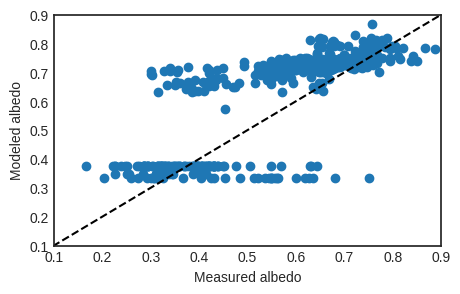

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(all_meas_albedo, all_mod_albedo, label='Data')
plt.plot([0,1], [0,1], 'k--',label='1:1')
plt.xlim(0.1, 0.9)
plt.ylim(0.1, 0.9)
plt.xlabel('Measured albedo')
plt.ylabel('Modeled albedo')
plt.show()

(<Figure size 640x480 with 1 Axes>, <Axes: >)

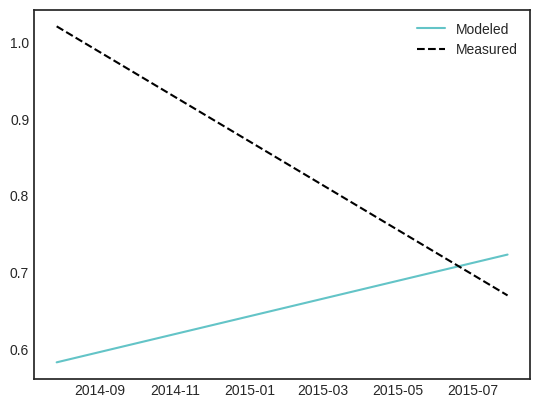

In [26]:
test_glac = 'taku'
test_site = 'MG1'
ds = xr.open_dataset(f'../../Output/{test_glac}{test_site}_2026_02_25_1.nc')

# plt.plot(ds.time.values, ds.isel(layer=0).layerBC.values)
# plt.show()
# plt.plot(ds.time.values, ds.isel(layer=0).layergrainsize.values)
# plt.show()

mb_data = MassBalance(test_glac, test_site, 'benchmark seasonal')
albedo_data = Albedo(test_glac, test_site)
albedo_data.get_model_albedo(ds)
# albedo_data.plot_timeseries()
# plt.show()

# plt.scatter(albedo_data.meas, albedo_data.mod)
# plt.plot([0,1],[0, 1], 'k--')
# plt.show()

mb_data.get_model_mb(ds)
mb_data.plot_mb()

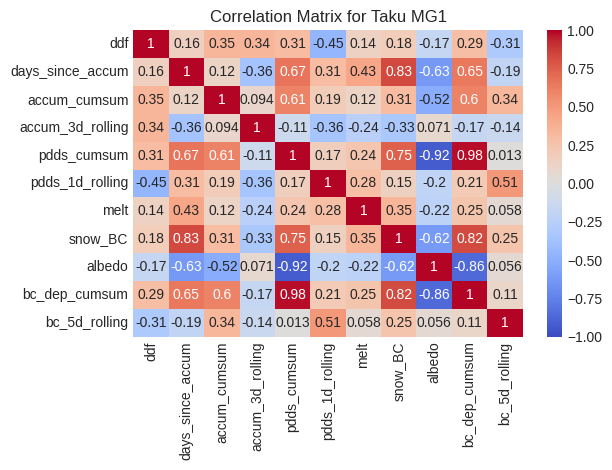

In [126]:
from get_ddf import get_ddf_df 
ds_bc = xr.open_dataarray(home_fp + 'climate_data/MERRA2/60.5_-148.7/BCDP002_60.5_-148.7.nc')
df = get_ddf_df(ds, ds_bc, plot_corr=True, n_rolling_bc=5, n_rolling_pdds=1)

In [128]:
import statsmodels.api as sm
# df['BC_eff'] = df['bc_1d_rolling'].ewm(halflife=3).mean()

# df must contain columns: 'melt', 'PDD', 'BC'
X = df[['pdds_1d_rolling', 'bc_dep_cumsum']]
y = df['melt']

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.751
Model:                            OLS   Adj. R-squared (uncentered):              0.745
Method:                 Least Squares   F-statistic:                              119.2
Date:                Tue, 24 Feb 2026   Prob (F-statistic):                    1.40e-24
Time:                        16:24:17   Log-Likelihood:                         -374.87
No. Observations:                  81   AIC:                                      753.7
Df Residuals:                      79   BIC:                                      758.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------